<a href="https://colab.research.google.com/github/Sarasii22/Broadband-Fraud-Management-System/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_parquet(
    "/content/drive/MyDrive/Intern/dataset.parquet"
)

In [4]:
df.head()

,subscriber_id,record_opening_time,record_closing_time,cc_total_octets_bytes,cc_input_octets_bytes,cc_output_octets_bytes,load_date
0,SUB_365EECB8,2026-05-16 11:00:00,2026-05-16 10:00:00,0,8094,0,2026-05-17 05:04:50
1,SUB_18F7320C,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104908831,3101465,2026-05-17 05:04:50
2,SUB_291441E6,2026-05-16 11:00:00,2026-05-16 10:00:00,0,1265702,0,2026-05-17 05:04:50
3,SUB_DF3164B0,2026-05-16 11:00:00,2026-05-16 10:00:00,0,11306,0,2026-05-17 05:04:50
4,SUB_A7EA0B37,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104970480,576504,2026-05-17 05:04:50


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700000 entries, 0 to 2699999
Data columns (total 7 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   subscriber_id           object        
 1   record_opening_time     datetime64[ns]
 2   record_closing_time     datetime64[ns]
 3   cc_total_octets_bytes   int64         
 4   cc_input_octets_bytes   int64         
 5   cc_output_octets_bytes  int64         
 6   load_date               datetime64[ns]
dtypes: datetime64[ns](3), int64(3), object(1)
memory usage: 144.2+ MB


In [6]:
df.shape

(2700000, 7)

check null and duplicates

In [7]:
df.isnull().sum()

,0
subscriber_id,0
record_opening_time,0
record_closing_time,0
cc_total_octets_bytes,0
cc_input_octets_bytes,0
cc_output_octets_bytes,0
load_date,0


In [9]:
df.duplicated().sum()

np.int64(18627)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(2681373, 7)

Bytes to MB

In [12]:
# Convert bytes to MB
df["download_mb"] = df["cc_input_octets_bytes"] / (1024 * 1024)
df["upload_mb"] = df["cc_output_octets_bytes"] / (1024 * 1024)

# Calculate total usage in MB
df["total_usage_mb"] = df["download_mb"] + df["upload_mb"]

# Display the new columns
print(df[[
    "cc_input_octets_bytes",
    "cc_output_octets_bytes",
    "download_mb",
    "upload_mb",
    "total_usage_mb"
]].head())

   cc_input_octets_bytes  cc_output_octets_bytes  download_mb  upload_mb  \
0                   8094                       0     0.007719   0.000000   
1              104908831                 3101465   100.048858   2.957788   
2                1265702                       0     1.207067   0.000000   
3                  11306                       0     0.010782   0.000000   
4              104970480                  576504   100.107651   0.549797   

   total_usage_mb  
0        0.007719  
1      103.006645  
2        1.207067  
3        0.010782  
4      100.657448  


/tmp/ipykernel_915/2361956741.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["download_mb"] = df["cc_input_octets_bytes"] / (1024 * 1024)
/tmp/ipykernel_915/2361956741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["upload_mb"] = df["cc_output_octets_bytes"] / (1024 * 1024)
/tmp/ipykernel_915/2361956741.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [13]:
print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")
print("="*50)
print("Column Names")
print("="*50)
print(df.columns.tolist())

print("\n")
print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")
print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

Dataset Shape
(2681373, 10)


Column Names
['subscriber_id', 'record_opening_time', 'record_closing_time', 'cc_total_octets_bytes', 'cc_input_octets_bytes', 'cc_output_octets_bytes', 'load_date', 'download_mb', 'upload_mb', 'total_usage_mb']


Data Types
subscriber_id                     object
record_opening_time       datetime64[ns]
record_closing_time       datetime64[ns]
cc_total_octets_bytes              int64
cc_input_octets_bytes              int64
cc_output_octets_bytes             int64
load_date                 datetime64[ns]
download_mb                      float64
upload_mb                        float64
total_usage_mb                   float64
dtype: object


Missing Values
subscriber_id             0
record_opening_time       0
record_closing_time       0
cc_total_octets_bytes     0
cc_input_octets_bytes     0
cc_output_octets_bytes    0
load_date                 0
download_mb               0
upload_mb                 0
total_usage_mb            0
dtype: int64


In [14]:
print("Unique Subscribers:", df["subscriber_id"].nunique())

Unique Subscribers: 512705


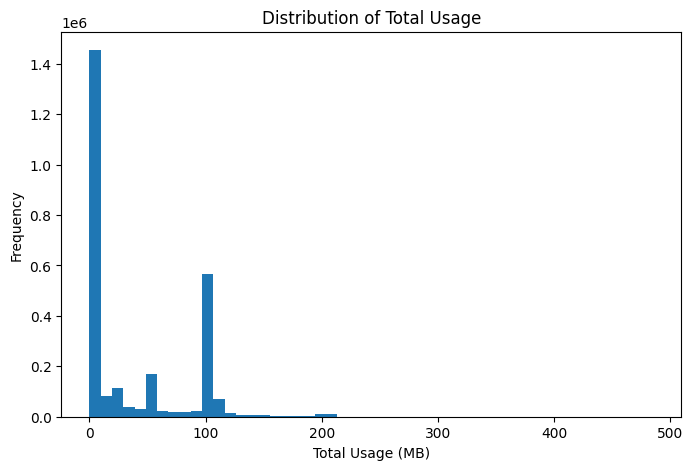

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["total_usage_mb"], bins=50)
plt.xlabel("Total Usage (MB)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Usage")
plt.show()

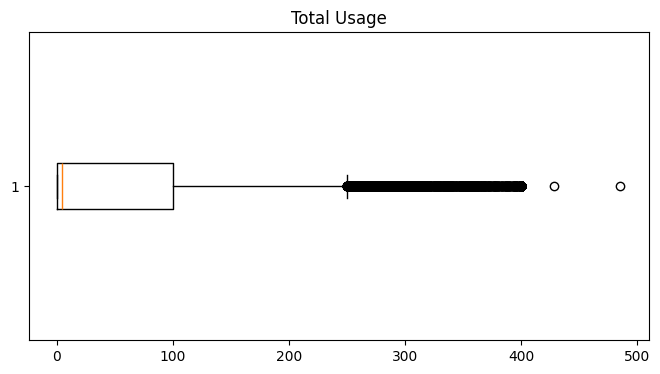

In [16]:
plt.figure(figsize=(8,4))
plt.boxplot(df["total_usage_mb"], vert=False)
plt.title("Total Usage")
plt.show()

In [17]:
print(df["total_usage_mb"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

0.50      4.662180
0.75    100.006155
0.90    103.836155
0.95    107.497655
0.99    195.741616
Name: total_usage_mb, dtype: float64


In [18]:
print(df[[
    "download_mb",
    "upload_mb"
]].describe())

        download_mb     upload_mb
count  2.681373e+06  2.681373e+06
mean   2.664529e+01  1.129129e+01
std    4.347087e+01  2.702518e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  5.340576e-05
50%    7.771120e-01  5.600185e-01
75%    5.000711e+01  3.740119e+00
max    4.135383e+02  4.853148e+02


In [20]:
daily_usage = (
    df.groupby(["subscriber_id", "load_date"])["total_usage_mb"]
      .sum()
)

print(daily_usage.describe())

count    512705.000000
mean        198.402821
std         440.213781
min           0.000028
25%           3.465756
50%         100.006887
75%         232.323649
max       72096.349815
Name: total_usage_mb, dtype: float64


In [21]:
sessions = (
    df.groupby("subscriber_id")
      .size()
)

print(sessions.describe())

count    512705.000000
mean          5.229855
std           8.232371
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max        4358.000000
dtype: float64


In [22]:
subscriber_profile = df.groupby("subscriber_id").agg(

    total_download_mb = ("download_mb","sum"),
    total_upload_mb = ("upload_mb","sum"),
    total_usage_mb = ("total_usage_mb","sum"),
    avg_usage_mb = ("total_usage_mb", 'mean'),
    max_usage_mb = ("total_usage_mb", "max"),
    Number_of_sessions = ("record_opening_time","count")


)

In [23]:
#disable scientific notation

pd.set_option('display.float_format', '{:.5f}'.format)

In [24]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
subscriber_id,,,,,,
SUB_00000326,11.27373,54.40195,65.67568,10.94595,50.00805,6
SUB_00001E72,4.90480,0.00000,4.90480,2.45240,4.83538,2
SUB_000048C2,31.77706,700.49108,732.26814,43.07460,100.13471,17
SUB_0000573D,0.19353,0.06723,0.26077,0.05215,0.06518,5
SUB_00005906,26.34410,39.26876,65.61286,21.87095,51.28535,3
...,...,...,...,...,...,...
SUB_FFFFA359,3.76679,0.96731,4.73410,2.36705,4.70216,2
SUB_FFFFD0A0,5.64014,102.81592,108.45606,36.15202,102.81592,3
SUB_FFFFD502,0.53010,1.00559,1.53569,0.25595,0.36524,6


count how many records have the closing time after the opening time:

In [25]:
count = (df["record_closing_time"] > df["record_opening_time"]).sum()
print("closing time > Opening time ", count)

closing time > Opening time  1986834


In [26]:
count = (df["record_closing_time"] < df["record_opening_time"]).sum()
print("closing time < Opening time ", count)

closing time < Opening time  603869


In [27]:
subscriber_profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 512705 entries, SUB_00000326 to SUB_FFFFEC62
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   total_download_mb   512705 non-null  float64
 1   total_upload_mb     512705 non-null  float64
 2   total_usage_mb      512705 non-null  float64
 3   avg_usage_mb        512705 non-null  float64
 4   max_usage_mb        512705 non-null  float64
 5   Number_of_sessions  512705 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 27.4+ MB


In [28]:
subscriber_profile.describe().T

,count,mean,std,min,25%,50%,75%,max
total_download_mb,512705.00000,139.35103,382.06225,0.00000,0.57344,9.40920,151.56271,70929.99216
total_upload_mb,512705.00000,59.05179,153.45248,0.00000,0.66416,8.14599,63.97125,18006.26569
total_usage_mb,512705.00000,198.40282,440.21378,0.00003,3.46576,100.00689,232.32365,72096.34982
avg_usage_mb,512705.00000,32.17013,35.80360,0.00003,1.19462,20.11507,51.82163,400.00350
max_usage_mb,512705.00000,61.78268,56.45666,0.00003,2.46464,53.09980,102.55655,485.31480
Number_of_sessions,512705.00000,5.22986,8.23237,1.00000,2.00000,4.00000,7.00000,4358.00000


In [29]:
subscriber_profile.corr()

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
total_download_mb,1.00000,0.20697,0.94005,0.47744,0.39918,0.43949
total_upload_mb,0.20697,1.00000,0.52822,0.21272,0.30677,0.36413
total_usage_mb,0.94005,0.52822,1.00000,0.48852,0.45339,0.50836
avg_usage_mb,0.47744,0.21272,0.48852,1.00000,0.79059,0.10232
max_usage_mb,0.39918,0.30677,0.45339,0.79059,1.00000,0.20803
Number_of_sessions,0.43949,0.36413,0.50836,0.10232,0.20803,1.00000


Scale features

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(subscriber_profile)
X_scaled.shape

(512705, 6)

In [31]:
X_scaled

array([[-0.33522658, -0.03030155, -0.3015064 , -0.5927953 , -0.20856084,
         0.09355086],
       [-0.35189648, -0.38482173, -0.43955509, -0.83002151, -1.00869157,
        -0.39233638],
       [-0.28156165,  4.18005584,  1.21274222,  0.30456356,  0.67931868,
         1.42974078],
       ...,
       [-0.36334673, -0.37826863, -0.44720846, -0.89136886, -1.08786991,
         0.09355086],
       [-0.3183343 ,  1.68309253,  0.31042007,  0.27124674,  0.67996714,
         0.33649448],
       [-0.34099569, -0.2025317 , -0.36655048, -0.75071739, -0.61246951,
         0.21502267]])

ISOLATION FOREST

In [32]:
#Start with 1% contamination. This means we assume about 1% of subscribers are anomalous.
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators = 100,
    contamination = 0.01,
    random_state = 42
)

model.fit(X_scaled)

IsolationForest(contamination=0.01, random_state=42)

In [33]:
subscriber_profile["anomaly"] = model.predict(X_scaled)
subscriber_profile["anomaly"]

,anomaly
subscriber_id,
SUB_00000326,1
SUB_00001E72,1
SUB_000048C2,1
SUB_0000573D,1
SUB_00005906,1
...,...
SUB_FFFFA359,1
SUB_FFFFD0A0,1
SUB_FFFFD502,1


In [34]:
subscriber_profile["anomaly"].value_counts()

,count
anomaly,
1,507577
-1,5128


In [35]:
subscriber_profile["anomaly_score"] = model.decision_function(X_scaled)

In [36]:
subscriber_profile.sort_values(
    by = "anomaly_score"
)

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score
subscriber_id,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,-1,-0.17327
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,-1,-0.17212
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,-1,-0.16927
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,-1,-0.16189
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,-1,-0.16019
...,...,...,...,...,...,...,...,...
SUB_4210F982,0.17571,0.21621,0.39192,0.19596,0.35677,2,1,0.31361
SUB_294E94CC,0.17466,0.19140,0.36606,0.18303,0.33994,2,1,0.31361
SUB_AA136F15,0.19211,0.19528,0.38739,0.19370,0.36209,2,1,0.31361


In [37]:
subscriber_profile["fraud_status"] = subscriber_profile["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [38]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly,anomaly_score,fraud_status
subscriber_id,,,,,,,,,
SUB_00000326,11.27373,54.40195,65.67568,10.94595,50.00805,6,1,0.26102,Normal
SUB_00001E72,4.90480,0.00000,4.90480,2.45240,4.83538,2,1,0.28341,Normal
SUB_000048C2,31.77706,700.49108,732.26814,43.07460,100.13471,17,1,0.05613,Normal
SUB_0000573D,0.19353,0.06723,0.26077,0.05215,0.06518,5,1,0.30299,Normal
SUB_00005906,26.34410,39.26876,65.61286,21.87095,51.28535,3,1,0.26648,Normal
...,...,...,...,...,...,...,...,...,...
SUB_FFFFA359,3.76679,0.96731,4.73410,2.36705,4.70216,2,1,0.28961,Normal
SUB_FFFFD0A0,5.64014,102.81592,108.45606,36.15202,102.81592,3,1,0.27660,Normal
SUB_FFFFD502,0.53010,1.00559,1.53569,0.25595,0.36524,6,1,0.29073,Normal
